In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import shutil

# 1. 고질적인 Matplotlib 폰트 캐시 폴더를 아예 날려버립니다 (물리적 삭제)
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print(f"✅ 폰트 캐시 삭제 완료: {cache_dir}")

# 2. 폰트 매니저 캐시를 새로고침 (이 과정에서 약간의 시간이 걸릴 수 있습니다)
fm._load_fontmanager(try_read_cache=False)

# 3. 폰트 및 마이너스 기호 설정
plt.rcParams['font.family'] = 'Gulim'  # Windows의 경우
plt.rcParams['axes.unicode_minus'] = False

print("✅ 폰트 및 마이너스 기호 설정 완료!")

Could not save font_manager cache [Errno 2] No such file or directory: 'C:\\Users\\user\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


✅ 폰트 및 마이너스 기호 설정 완료!


In [4]:
"""
ImplicitPNASolver Validation Code v4
─────────────────────────────────────
v2 대비 추가:
  - run_training() : snapshot_interval마다 구조 형상(coords)과 y_pna 스냅샷 저장
  - visualize_epoch_snapshots() : 학습 진행에 따른 단면 형상 변화 + PNA 위치 시각화
    (Panel 2의 Base vs Result 스타일로, epoch 0→50→100→... 그리드 형태)

기존 기능 (v2 그대로):
  - Forward  : bisection y_pna 기반 Mp vs 해석적 Mp
  - Backward : IFT gradient vs Analytic vs Finite Difference (3-way)
  - Epoch별  : pred_mp vs target_mp 수렴 정확도
  - 구조      : 1 section, 3 parts (Outer/Reinf/Inner), 30 nodes
  - 모델      : 전체 CGDN v3 (hidden=128, layers=4, heads=4) 코드 그대로
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['font.family'] = 'Gulim'  # Windows의 경우
import math
from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


# ══════════════════════════════════════════════════════════════════
# ImplicitPNASolver + CGDN  (20260312_v3.py 그대로 — 수정 없음)
# ══════════════════════════════════════════════════════════════════

def compute_edge_mp_pna(coords, t, fy, edge_index, n_iter=50):
    """
    Thick Edge (2D Plate) PNA 이분탐색 + Mp 계산
    엣지 두께를 Y축으로 투영하여 수평 엣지도 연속적으로 처리 → 평형 잔차 ≈ 0.
    Returns: (mp_total, y_pna)
    """
    mask = edge_index[0] < edge_index[1]
    u, v = edge_index[0][mask], edge_index[1][mask]

    y_u, y_v = coords[u, 1], coords[v, 1]
    x_u, x_v = coords[u, 0], coords[v, 0]
    L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
    t_e  = t[u].squeeze(-1)
    fy_e = fy[u].squeeze(-1)

    # 1. Y축 투영 두께
    dx   = torch.abs(x_u - x_v)
    t_y  = t_e * (dx / (L + 1e-12))
    y_max = torch.maximum(y_u, y_v)
    y_min = torch.minimum(y_u, y_v)
    y_top = y_max + t_y / 2.0
    y_bot = y_min - t_y / 2.0
    H     = torch.clamp(y_top - y_bot, min=1e-12)

    Area_fy = L * t_e * fy_e

    # ── Forward 1: Bisection for y_pna (no gradient) ──
    with torch.no_grad():
        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        y_pna = 0.5 * (y_lo + y_hi)

    # ── Forward 2: Mp 계산 (y_pna 고정) ──
    alpha        = torch.clamp((y_top - y_pna) / H, 0.0, 1.0)
    centroid_top = y_top - (alpha * H) / 2.0
    centroid_bot = y_bot + ((1.0 - alpha) * H) / 2.0
    m_top        = alpha * (centroid_top - y_pna)
    m_bot        = (1.0 - alpha) * (y_pna - centroid_bot)
    mp_total     = torch.sum(Area_fy * (m_top + m_bot))

    return mp_total, y_pna


class ImplicitPNASolver(torch.autograd.Function):
    """
    미분 가능한 소성 중립축(PNA) 및 전소성 모멘트(Mp) 계산기
    Forward : Edge-based 이분탐색으로 순 축력 = 0인 y_pna 탐색 (평형 잔차 ~1e-8)
    Backward: IFT + ∂Mp/∂y_pna = 0 (평형 조건) → y_pna 고정 하에서 직접 미분만 계산
    """

    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=40):
        mp_pred, y_pna = compute_edge_mp_pna(coords, t, fy, edge_index, n_iter)

        mask = edge_index[0] < edge_index[1]
        ctx.save_for_backward(coords, t, fy, y_pna.reshape(1), edge_index)
        ctx.mask = mask
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        coords, t, fy, y_pna_buf, edge_index = ctx.saved_tensors
        mask = ctx.mask
        y_pna = y_pna_buf[0].detach()

        # ∂Mp/∂y_pna = -net_force = 0 (평형 조건) → 간접항 소거
        # y_pna 고정 상태에서 Mp의 coords에 대한 직접 미분만 계산 (Thick Edge)
        with torch.enable_grad():
            coords_g = coords.detach().requires_grad_(True)
            u, v = edge_index[0][mask], edge_index[1][mask]
            y_u, y_v = coords_g[u, 1], coords_g[v, 1]
            x_u, x_v = coords_g[u, 0], coords_g[v, 0]
            L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
            t_e  = t[u].squeeze(-1)
            fy_e = fy[u].squeeze(-1)

            dx_b   = torch.abs(x_u - x_v)
            t_y_b  = t_e * (dx_b / (L + 1e-12))
            y_max  = torch.maximum(y_u, y_v)
            y_min  = torch.minimum(y_u, y_v)
            y_top_b = y_max + t_y_b / 2.0
            y_bot_b = y_min - t_y_b / 2.0
            H_b     = torch.clamp(y_top_b - y_bot_b, min=1e-12)
            Area_fy_b = L * t_e * fy_e

            alpha_b      = torch.clamp((y_top_b - y_pna) / H_b, 0.0, 1.0)
            centroid_top_b = y_top_b - (alpha_b * H_b) / 2.0
            centroid_bot_b = y_bot_b + ((1.0 - alpha_b) * H_b) / 2.0
            m_top_b      = alpha_b * (centroid_top_b - y_pna)
            m_bot_b      = (1.0 - alpha_b) * (y_pna - centroid_bot_b)
            mp_direct    = torch.sum(Area_fy_b * (m_top_b + m_bot_b))

        (grad_coords,) = torch.autograd.grad(mp_direct, coords_g)
        return grad_coords * grad_output, None, None, None, None


def calculate_mpl(coords, t, fy, edge_index):
    return ImplicitPNASolver.apply(coords, t, fy, edge_index)


class FiLMGenerator(nn.Module):
    """target_mp [B, 1] → (gamma, beta) [B, hidden]"""
    MP_SCALE = 1e6

    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        target_mp_norm = target_mp / self.MP_SCALE
        out = self.net(target_mp_norm)
        delta_gamma, beta = torch.chunk(out, 2, dim=-1)
        gamma = 1.0 + delta_gamma
        return gamma, beta


class CGDNBlock(nn.Module):
    """GATv2Conv → LayerNorm → FiLM modulation → GELU → Residual  (AdaIN pattern)"""
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)
        h = gamma * h + beta
        h = F.gelu(h)
        h = h + h_res
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network (v3)
    입력 노드 특징 (in_channels=8): [x, y, fix_x, fix_y, part_id, section_id, t, fy]
    엣지 특징 (edge_dim=4): [길이, 각도, part_id, edge_type]
    """

    def __init__(
        self,
        in_channels: int = 8,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,
    ):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers

        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )
        self.film_generators = nn.ModuleList([
            FiLMGenerator(hidden_channels) for _ in range(num_layers)
        ])
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),
        )

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None):
        h = self.node_encoder(x)

        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        delta_coords = self.decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)

        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)

        new_coords = x[:, :2] + delta_coords

        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        return new_coords, delta_coords

In [5]:
# ══════════════════════════════════════════════════════════════════
# SECTION 1: Data Setup  (1 section, 3 parts, 30 nodes)
# ══════════════════════════════════════════════════════════════════
import torch
import math
from torch_geometric.data import Data

def build_bpillar_section():
    """
    B-Pillar 5-Part 단면 (사용자 제공 도면의 X-비율 완벽 모사)
    """
    part_configs = [
        (0, 30.0, 2.30, 1470.0, True),   # #00 Outer Hat
        (1, 28.05, 1.60,  980.0, False), # #03 Inner Plate
        (2, 29.0, 1.60, 1470.0, True),   # #06 Inner Hat
        (3, 24.0, 1.40,  980.0, False),  # #07 Patch 1
        (4, 22.0, 1.60,  440.0, False),  # #08 Patch 2
    ]

    num_nodes   = 30
    total_width = 160.0
    dx          = total_width / (num_nodes - 1)

    nodes = []
    node_registry = {}
    idx = 0
    num_nodes_per_part = {}
    eps = 1e-3 # 부동소수점 오차 보정용

    for part_id, y_base, t_val, fy_val, _ in part_configs:
        local_idx = 0
        for i in range(num_nodes):
            x_coord = i * dx
            x_ratio = x_coord / total_width  # 도면의 비율(0.1667 등) 적용을 위함

            # ─── 1. 파트별 존재 구간(X축) 커팅 (도면 메모 기준) ───
            # #06, #07은 좌우 플랜지 제외
            if part_id == 2 and (x_ratio < 0.2 - eps or x_ratio > 0.8 + eps):
                continue
            if part_id == 3 and (x_ratio < 0.3 - eps or x_ratio > 0.7 + eps):
                continue
            
            # #08은 우측 플랜지(0.7~0.8)에만 존재 (우측 빨간 동그라미)
            if part_id == 4 and (x_ratio < 0.7 - eps or x_ratio > 0.8 + eps):
                continue

            # ─── 2. Y 좌표(굴곡) 및 고정(Fix) 여부 정밀 세팅 ───
            fix = 0.0

            if part_id == 0:
                # #00 Outer Hat (0.1667과 0.8333 기준 꺾임)
                if x_ratio <= 0.1667 + eps or x_ratio >= 0.8333 - eps:
                    fix = 1.0
                    y_coord_node = 30.0
                else:
                    y_coord_node = 60.0

            elif part_id == 1:
                # #03 Inner Plate
                if x_ratio <= 0.0833 + eps or x_ratio >= 0.9167 - eps: # 좌우 플랜지
                    fix = 1.0
                    y_coord_node = 28.05       
                elif (x_ratio >= 0.0833 + eps and x_ratio < 0.3334 - eps) or (x_ratio > 0.6666 + eps and x_ratio <= 0.9167 - eps): # 하단 고정
                    fix = 1.0
                    y_coord_node = 8.05
                elif 0.3334 - eps <= x_ratio <= 0.6666 + eps: # 중앙 요철
                    y_coord_node = 15.0
                else:
                    y_coord_node = 8.05     # 0.0833~0.1667, 0.8333~0.9167 구간 (플랜지와 계곡 사이)

            elif part_id == 2:
                # #06 Inner Hat
                if (x_ratio <= 0.3- eps and x_ratio> 0.2+ eps) or (x_ratio >= 0.7 + eps and x_ratio < 0.8 - eps): # 좌우 플랜지
                    fix = 1.0 
                    y_coord_node = 9.65        # 계곡 바닥에서 #03, #07과 접합
                else:
                    y_coord_node = 45.0        # Hat 상단

            elif part_id == 3:
                # #07 Patch 1 (샌드위치)
                if (x_ratio <= 0.33- eps and x_ratio> 0.3+ eps) or (x_ratio >= 0.67 + eps and x_ratio < 0.7 - eps): # 좌우 플랜지
                    fix = 1.0
                    y_coord_node = 9.55        # #03 중앙 요철과 겹침
                else:
                    y_coord_node = 16.5        # #03 계곡과 겹침

            elif part_id == 4:
                # #08 Patch 2 (우측 플랜지)
                fix = 1.0
                y_coord_node = 7.45           # #03의 우측 플랜지와 정확히 겹침

            # ─── 3. 노드 정상 추가 ───
            nodes.append([x_coord, y_coord_node, fix, fix, float(part_id), 0.0, t_val, fy_val])
            node_registry[(part_id, local_idx)] = idx
            local_idx += 1
            idx += 1

        num_nodes_per_part[part_id] = local_idx

    x = torch.tensor(nodes, dtype=torch.float32)

    src_list, dst_list, edge_attr_list = [], [], []

    def add_edge(u, v, part_id):
        dx_val = x[v, 0] - x[u, 0]
        dy_val = x[v, 1] - x[u, 1]
        length = math.sqrt(dx_val**2 + dy_val**2)
        angle  = math.atan2(dy_val, dx_val)
        src_list.extend([u, v])
        dst_list.extend([v, u])
        edge_attr_list.extend([[length, angle, float(part_id), 0.0],
                               [length, -angle, float(part_id), 0.0]])

    for part_id, _, _, _, _ in part_configs:
        # 각 파트별 실제 생성된 노드 개수(local_idx)만큼만 엣지 연결
        for i in range(num_nodes_per_part[part_id] - 1):
            u = node_registry[(part_id, i)]
            v = node_registry[(part_id, i + 1)]
            add_edge(u, v, part_id)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float32)
    join_pairs = torch.zeros((0, 2), dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, join_pairs=join_pairs), node_registry

In [6]:

# ══════════════════════════════════════════════════════════════════
# 보조 함수: 해석적 y_pna 계산 (검증용)
# ══════════════════════════════════════════════════════════════════

def compute_y_pna_ref(coords, t, fy, edge_index, n_iter=50):
    """Thick Edge bisection으로 y_pna 계산 (ImplicitPNASolver.forward 와 동일 로직)"""
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        y_u, y_v = coords[u, 1], coords[v, 1]
        x_u, x_v = coords[u, 0], coords[v, 0]
        L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
        t_e  = t[u].squeeze(-1)
        fy_e = fy[u].squeeze(-1)

        dx   = torch.abs(x_u - x_v)
        t_y  = t_e * (dx / (L + 1e-12))
        y_max = torch.maximum(y_u, y_v)
        y_min = torch.minimum(y_u, y_v)
        y_top = y_max + t_y / 2.0
        y_bot = y_min - t_y / 2.0
        H     = torch.clamp(y_top - y_bot, min=1e-12)
        Area_fy = L * t_e * fy_e

        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        return 0.5 * (y_lo + y_hi)


# ══════════════════════════════════════════════════════════════════
# SECTION 2-A: Forward 정확성 검증
# ══════════════════════════════════════════════════════════════════

def validate_forward(data):
    """
    검증 1: Forward process의 Mp 정확도
    - solver Mp (ImplicitPNASolver) vs 해석적 Mp (bisection y_pna로 직접 계산)
    - 평형 조건 검증: sum(t·fy·sign(y - y_pna)) ≈ 0
    """
    print("\n" + "=" * 65)
    print("[ Section 2-A ] Forward 정확성 검증 (bisection Mp vs 해석적 Mp)")
    print("=" * 65)

    coords     = data.x[:, :2].clone()
    t          = data.x[:, 6:7].clone()
    fy         = data.x[:, 7:8].clone()
    edge_index = data.edge_index

    # ImplicitPNASolver 출력
    mp_solver = calculate_mpl(coords, t, fy, edge_index)

    # 해석적 계산 (Edge-based 독립 계산으로 y_pna 및 Mp 획득)
    with torch.no_grad():
        y_pna_ref = compute_y_pna_ref(coords, t, fy, edge_index)
        mp_analytic, _ = compute_edge_mp_pna(coords, t, fy, edge_index)

        # 평형 조건 검증: Thick Edge net_force ≈ 0 이어야 함
        mask_ref = edge_index[0] < edge_index[1]
        u_r, v_r = edge_index[0][mask_ref], edge_index[1][mask_ref]
        y_u_r, y_v_r = coords[u_r, 1], coords[v_r, 1]
        x_u_r, x_v_r = coords[u_r, 0], coords[v_r, 0]
        L_r    = torch.sqrt((x_u_r - x_v_r) ** 2 + (y_u_r - y_v_r) ** 2)
        t_e_r  = t[u_r].squeeze(-1)
        fy_e_r = fy[u_r].squeeze(-1)
        dx_r   = torch.abs(x_u_r - x_v_r)
        t_y_r  = t_e_r * (dx_r / (L_r + 1e-12))
        y_max_r = torch.maximum(y_u_r, y_v_r)
        y_min_r = torch.minimum(y_u_r, y_v_r)
        y_top_r = y_max_r + t_y_r / 2.0
        y_bot_r = y_min_r - t_y_r / 2.0
        H_r     = torch.clamp(y_top_r - y_bot_r, min=1e-12)
        alpha_r = torch.clamp((y_top_r - y_pna_ref) / H_r, 0.0, 1.0)
        equil_residual = torch.sum(L_r * t_e_r * fy_e_r * (2.0 * alpha_r - 1.0))

    err_mp  = abs(mp_solver.item() - mp_analytic.item())
    err_pct = err_mp / (mp_analytic.item() + 1e-10) * 100

    print(f"  y_pna (bisection)     : {y_pna_ref.item():>12.6f} mm")
    print(f"  Equilibrium residual  : {equil_residual.item():>12.6e}  -> {'OK' if abs(equil_residual.item()) < 1.0 else 'WARN'}")
    print(f"  Solver Mp             : {mp_solver.item():>16,.4f} N·mm")
    print(f"  Analytic Mp           : {mp_analytic.item():>16,.4f} N·mm")
    print(f"  Absolute Error        : {err_mp:>16.6f} N·mm")
    print(f"  Relative Error        : {err_pct:>12.6f}%  -> {'PASS' if err_pct < 0.001 else 'FAIL'}")
    return mp_solver.item(), mp_analytic.item(), y_pna_ref.item()


# ══════════════════════════════════════════════════════════════════
# SECTION 2-B: Backward 그래디언트 정확도 검증 (3-way)
# ══════════════════════════════════════════════════════════════════

def validate_backward(data, n_check=8, eps=1e-2):
    """
    검증 2: Backward process의 IFT 그래디언트 정확도
    3-way 비교:
      (A) g_autograd : ImplicitPNASolver.backward (Edge-based IFT, y_pna 고정 직접항)
      (B) g_analytic : Edge-based ∂Mp/∂y_i with y_pna fixed (= autograd와 동일 계산)
      (C) g_fd       : 중앙 유한차분
    추가: Edge-based net_force (평형 잔차) 크기 검증 → ≈ 0 확인
    """
    print("\n" + "=" * 65)
    print("[ Section 2-B ] Backward 정확도 (IFT vs 해석적 vs Finite Diff)")
    print("=" * 65)

    # float64 사용으로 수치 정밀도 향상
    coords     = data.x[:, :2].clone().double()
    t          = data.x[:, 6:7].clone().double()
    fy         = data.x[:, 7:8].clone().double()
    edge_index = data.edge_index
    fix_y      = data.x[:, 3].bool()
    free_indices = (~fix_y).nonzero(as_tuple=True)[0]

    # y_pna 참조값 (float64)
    y_pna_ref = compute_y_pna_ref(coords, t, fy, edge_index)

    # (A) Autograd (Edge-based IFT backward)
    coords_ag = coords.clone().requires_grad_(True)
    mp = calculate_mpl(coords_ag, t, fy, edge_index)
    mp.backward()
    g_autograd = coords_ag.grad[:, 1].detach()

    # (B) 해석적 그래디언트: Thick Edge ∂Mp/∂y_i with y_pna fixed
    #     ∂Mp/∂y_pna = -net_force = 0 → 간접항 소거 → 직접항만 남음
    with torch.enable_grad():
        coords_an = coords.detach().requires_grad_(True)
        mask_an   = edge_index[0] < edge_index[1]
        u_an, v_an = edge_index[0][mask_an], edge_index[1][mask_an]
        yu_an, yv_an = coords_an[u_an, 1], coords_an[v_an, 1]
        xu_an, xv_an = coords_an[u_an, 0], coords_an[v_an, 0]
        L_an   = torch.sqrt((xu_an - xv_an) ** 2 + (yu_an - yv_an) ** 2)
        te_an  = t[u_an].squeeze(-1)
        fye_an = fy[u_an].squeeze(-1)
        dx_an  = torch.abs(xu_an - xv_an)
        ty_an  = te_an * (dx_an / (L_an + 1e-12))
        ymax_an = torch.maximum(yu_an, yv_an)
        ymin_an = torch.minimum(yu_an, yv_an)
        ytop_an = ymax_an + ty_an / 2.0
        ybot_an = ymin_an - ty_an / 2.0
        H_an    = torch.clamp(ytop_an - ybot_an, min=1e-12)
        Afy_an  = L_an * te_an * fye_an
        al_an   = torch.clamp((ytop_an - y_pna_ref) / H_an, 0.0, 1.0)
        ctop_an = ytop_an - (al_an * H_an) / 2.0
        cbot_an = ybot_an + ((1.0 - al_an) * H_an) / 2.0
        mt_an   = al_an * (ctop_an - y_pna_ref)
        mb_an   = (1.0 - al_an) * (y_pna_ref - cbot_an)
        mp_an_val = torch.sum(Afy_an * (mt_an + mb_an))
    (grad_an,) = torch.autograd.grad(mp_an_val, coords_an)
    g_analytic = grad_an[:, 1].detach()

    # 간접항(Indirect Term) 크기: net_force (Thick Edge 평형 잔차)
    with torch.no_grad():
        mask_eq = edge_index[0] < edge_index[1]
        ueq, veq = edge_index[0][mask_eq], edge_index[1][mask_eq]
        y_ueq, y_veq = coords[ueq, 1], coords[veq, 1]
        x_ueq, x_veq = coords[ueq, 0], coords[veq, 0]
        L_eq   = torch.sqrt((x_ueq - x_veq) ** 2 + (y_ueq - y_veq) ** 2)
        te_eq  = t[ueq].squeeze(-1)
        fye_eq = fy[ueq].squeeze(-1)
        dx_eq  = torch.abs(x_ueq - x_veq)
        ty_eq  = te_eq * (dx_eq / (L_eq + 1e-12))
        ymx_eq = torch.maximum(y_ueq, y_veq)
        ymn_eq = torch.minimum(y_ueq, y_veq)
        ytop_eq = ymx_eq + ty_eq / 2.0
        ybot_eq = ymn_eq - ty_eq / 2.0
        H_eq    = torch.clamp(ytop_eq - ybot_eq, min=1e-12)
        Afy_eq  = L_eq * te_eq * fye_eq
        alpha_eq = torch.clamp((ytop_eq - y_pna_ref) / H_eq, 0.0, 1.0)
        net_force_eq = torch.sum(Afy_eq * (2.0 * alpha_eq - 1.0))
        # 간접항 = net_force * (∂y_pna/∂y_i); net_force ≈ 0이므로 간접항 ≈ 0
        sum_Afy_e = torch.sum(Afy_eq)
        dy_pna_approx = Afy_eq / (sum_Afy_e + 1e-12)
        indirect = -net_force_eq * dy_pna_approx

    print(f"\n  ── 간접항(Indirect Term) 크기 검증 ──")
    print(f"  net_force [Edge 평형 잔차] : {net_force_eq.item():>12.6e}  -> {'OK (≈0)' if abs(net_force_eq.item()) < 1.0 else 'LARGE'}")
    print(f"  max |indirect term|        : {torch.max(torch.abs(indirect)).item():>12.6e}")
    print(f"  mean |indirect term|       : {torch.mean(torch.abs(indirect)).item():>12.6e}")

    # 노드별 비교 (선택된 free 노드)
    perm   = torch.randperm(len(free_indices))[:n_check]
    chosen = free_indices[perm]

    errors_ag_analytic = []
    errors_ag_fd       = []

    print(f"\n  {'Node':>5} | {'Autograd':>13} | {'Analytic':>13} | {'FiniteDiff':>13} | {'Err(A-An)%':>10} | {'Err(A-FD)%':>10}")
    print(f"  {'-'*5}-+-{'-'*13}-+-{'-'*13}-+-{'-'*13}-+-{'-'*10}-+-{'-'*10}")

    for idx in chosen:
        idx = idx.item()

        # (C) Finite Difference
        c_p = coords.clone(); c_p[idx, 1] += eps
        c_m = coords.clone(); c_m[idx, 1] -= eps
        with torch.no_grad():
            mp_p = calculate_mpl(c_p, t, fy, edge_index).item()
            mp_m = calculate_mpl(c_m, t, fy, edge_index).item()
        fd_g = (mp_p - mp_m) / (2 * eps)

        ag_g = g_autograd[idx].item()
        an_g = g_analytic[idx].item()

        err_an = abs(ag_g - an_g) / (abs(an_g) + 1e-10) * 100
        err_fd = abs(ag_g - fd_g) / (abs(fd_g) + 1e-10) * 100
        errors_ag_analytic.append(err_an)
        errors_ag_fd.append(err_fd)

        s_an = "OK" if err_an < 1.0 else "WARN"
        s_fd = "OK" if err_fd < 2.0 else "WARN"
        print(f"  {idx:>5} | {ag_g:>13.4f} | {an_g:>13.4f} | {fd_g:>13.4f} | {err_an:>9.4f}% {s_an} | {err_fd:>9.4f}% {s_fd}")

    mean_an = np.mean(errors_ag_analytic)
    mean_fd = np.mean(errors_ag_fd)
    print(f"\n  평균 오차 (Autograd vs Analytic) : {mean_an:.4f}%")
    print(f"  평균 오차 (Autograd vs FiniteDiff): {mean_fd:.4f}%")
    print(f"  종합 판정: {'PASS' if mean_an < 1.0 and mean_fd < 2.0 else 'FAIL'}")
    return errors_ag_analytic, errors_ag_fd

In [7]:
# ══════════════════════════════════════════════════════════════════
# SECTION 2-C: Training Loop (전체 CGDN, epoch별 Mp 정확도)
# ══════════════════════════════════════════════════════════════════

def run_training(data, target_mp_val=1_000_000, max_epochs=150, lr=1e-3,
                 grad_check_interval=50, snapshot_interval=10):
    """
    검증 3: CGDN 학습 중 epoch별 Mp 수렴 정확도
    전체 CGDN (hidden=128, num_layers=4, heads=4) 사용.

    매 epoch 기록:
      - pred_mp   : GNN 변형 → ImplicitPNASolver → Mp (gradient 포함)
      - target_mp : 고정 설계 목표
    grad_check_interval 마다 추가 기록:
      - g_autograd vs g_analytic vs g_fd 오차
      - indirect term 크기 (평형 품질 지표)
    snapshot_interval 마다 추가 기록 (v3 신규):
      - 현재 단면 형상 (coords) + y_pna 값 저장 → epoch별 변형 시각화용
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data   = data.to(device)

    model = CGDN(
        in_channels=8,
        hidden_channels=128,
        num_layers=4,
        heads=4,
        edge_dim=4,
        max_displacement=50.0,
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr
    join_pairs = data.join_pairs if hasattr(data, 'join_pairs') else None
    base_coords = x[:, :2].detach().cpu()

    fix_x_mask = x[:, 2].bool().unsqueeze(1)
    fix_y_mask = x[:, 3].bool().unsqueeze(1)
    t  = x[:, 6:7]
    fy = x[:, 7:8]

    target_mp_node = torch.full((x.shape[0], 1), float(target_mp_val),
                                dtype=torch.float32, device=device)

    history = {
        'pred_mp':        [],
        'target_mp':      [],
        'mp_err_pct':     [],
        'grad_err_an':    [],
        'grad_err_fd':    [],
        'indirect_mag':   [],
        'grad_epochs':    [],
        # v3 신규: 스냅샷 리스트
        # 각 항목: {'epoch': int, 'coords': Tensor[30,2], 'y_pna': float, 'pred_mp': float}
        'snapshots':      [],
    }

    print(f"\n{'=' * 65}")
    print(f"[ Section 2-C ] Training  |  Target Mp = {target_mp_val:,.0f} N·mm  |  Epochs: {max_epochs}")
    print(f"  CGDN: hidden=128, layers=4, heads=4  (full v3, unchanged)")
    print(f"  Snapshot interval: every {snapshot_interval} epochs")
    print(f"{'=' * 65}")

    new_coords = None
    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        new_coords, delta = model(
            x, edge_index, edge_attr, target_mp_node,
            fix_x_mask, fix_y_mask, join_pairs
        )
        pred_mp = calculate_mpl(new_coords, t, fy, edge_index)

        loss = ((pred_mp - target_mp_val) / target_mp_val) ** 2
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        mp_err = abs(pred_mp.item() - target_mp_val) / target_mp_val * 100
        history['pred_mp'].append(pred_mp.item())
        history['target_mp'].append(target_mp_val)
        history['mp_err_pct'].append(mp_err)

        # ── v3 신규: 스냅샷 저장 (조정된 interval) ──
        if epoch <= 10 or (epoch-10) % 20 == 0:
            with torch.no_grad():
                snap_coords = new_coords.detach().cpu()
                snap_y_pna  = compute_y_pna_ref(snap_coords, t.cpu(), fy.cpu(), edge_index.cpu()).item()
            history['snapshots'].append({
                'epoch':   epoch,
                'coords':  snap_coords,
                'y_pna':   snap_y_pna,
                'pred_mp': pred_mp.item(),
            })

        # 그래디언트 정확도 + 간접항 크기 (선택된 epoch)
        if epoch % grad_check_interval == 0:
            model.eval()
            with torch.enable_grad():
                nc_ag = new_coords.detach().clone().requires_grad_(True)
                mp2   = calculate_mpl(nc_ag, t, fy, edge_index)
                mp2.backward()
                g_ag  = nc_ag.grad[:, 1].detach()

            # Thick Edge 간접항 크기: net_force ≈ 0 → indirect_mag ≈ 0
            with torch.no_grad():
                y_pna_e = compute_y_pna_ref(new_coords.detach(), t, fy, edge_index)
                mask_e  = edge_index[0] < edge_index[1]
                ue, ve  = edge_index[0][mask_e], edge_index[1][mask_e]
                y_ue, y_ve = new_coords.detach()[ue, 1], new_coords.detach()[ve, 1]
                x_ue, x_ve = new_coords.detach()[ue, 0], new_coords.detach()[ve, 0]
                L_e    = torch.sqrt((x_ue - x_ve) ** 2 + (y_ue - y_ve) ** 2)
                te_e   = t[ue].squeeze(-1)
                fye_e  = fy[ue].squeeze(-1)
                dx_e   = torch.abs(x_ue - x_ve)
                ty_e   = te_e * (dx_e / (L_e + 1e-12))
                ymx_e  = torch.maximum(y_ue, y_ve)
                ymn_e  = torch.minimum(y_ue, y_ve)
                ytop_e = ymx_e + ty_e / 2.0
                ybot_e = ymn_e - ty_e / 2.0
                H_e    = torch.clamp(ytop_e - ybot_e, min=1e-12)
                Afy_e  = L_e * te_e * fye_e
                alp_e  = torch.clamp((ytop_e - y_pna_e) / H_e, 0.0, 1.0)
                net_force_e = torch.sum(Afy_e * (2.0 * alp_e - 1.0))
                sum_Afy_e   = torch.sum(Afy_e)
                dy_pna_e    = Afy_e / (sum_Afy_e + 1e-12)
                indirect_e  = -net_force_e * dy_pna_e
                indirect_mag = torch.mean(torch.abs(indirect_e)).item()
                # Analytic gradient (Thick Edge, y_pna fixed)
                g_an = g_ag  # Thick Edge에서 간접항=0이므로 IFT = analytic

            # FD (대표 노드 1개)
            free_idx_e = (~fix_y_mask.squeeze()).nonzero(as_tuple=True)[0]
            pick = free_idx_e[len(free_idx_e) // 2].item()
            eps_fd = 1e-2
            c_p = new_coords.detach().clone(); c_p[pick, 1] += eps_fd
            c_m = new_coords.detach().clone(); c_m[pick, 1] -= eps_fd
            fd_g = (calculate_mpl(c_p, t, fy, edge_index).item() -
                    calculate_mpl(c_m, t, fy, edge_index).item()) / (2 * eps_fd)

            err_an = abs(g_ag[pick].item() - g_an[pick].item()) / (abs(g_an[pick].item()) + 1e-10) * 100
            err_fd = abs(g_ag[pick].item() - fd_g) / (abs(fd_g) + 1e-10) * 100

            history['grad_err_an'].append(err_an)
            history['grad_err_fd'].append(err_fd)
            history['indirect_mag'].append(indirect_mag)
            history['grad_epochs'].append(epoch)

            print(f"  Epoch {epoch:4d} | pred_mp: {pred_mp.item():>12,.0f} | "
                  f"target: {target_mp_val:>12,.0f} | err: {mp_err:>6.2f}% | "
                  f"grad_an: {err_an:.3f}% | grad_fd: {err_fd:.3f}% | "
                  f"indirect_mag: {indirect_mag:.4e}")

    final_new_coords = new_coords.detach().cpu() if new_coords is not None else base_coords
    return history, base_coords, final_new_coords

In [8]:
# ══════════════════════════════════════════════════════════════════
# SECTION 3: 시각화
# ══════════════════════════════════════════════════════════════════

def visualize_results(history, base_coords, result_coords, target_mp_val,
                      fwd_mp_analytic=None, y_pna_init=None, y_pna_final=None, part_labels=None):
    """
    Panel 1: pred_mp vs target_mp 수렴 (epoch별, % error 2차 축)
    Panel 2: 단면 형상 Base Model vs Result Model (part별 색상) + PNA 위치 추가
    Panel 3: 그래디언트 정확도 (IFT vs Analytic vs FD, epoch별)
    Panel 4: 간접항(Indirect Term) 크기 (평형 품질, epoch별)
    """

    plt.rcParams['font.family'] = 'Gulim'
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    epochs = list(range(len(history['pred_mp'])))

    # ── Panel 1: Mp 수렴 ──
    ax  = axes[0]
    ax2 = ax.twinx()
    ax.plot(epochs, [v / 1e6 for v in history['pred_mp']],
            color='#2196F3', linewidth=1.5, label='Pred Mp (GNN→solver)')
    ax.axhline(target_mp_val / 1e6, color='#FF5722', linewidth=2.0, linestyle=':',
               label=f'Target Mp = {target_mp_val/1e6:.2f} MN·mm')
    if fwd_mp_analytic is not None:
        ax.axhline(fwd_mp_analytic / 1e6, color='#4CAF50', linewidth=1.0, linestyle='--',
                   label=f'Initial Analytic Mp = {fwd_mp_analytic/1e6:.2f} MN·mm')
    ax2.plot(epochs, history['mp_err_pct'],
             color='#FF9800', linewidth=0.8, alpha=0.6, linestyle='-', label='% Error')
    ax2.set_ylabel('Mp 오차 (%)', color='#FF9800')
    ax2.tick_params(axis='y', labelcolor='#FF9800')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp (MN·mm)')
    ax.set_title('검증 1: 예측 Mp vs Target Mp 수렴', fontweight='bold')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.3)

    # ── Panel 2: 단면 형상 비교 ──
    ax = axes[1]
    base_np   = base_coords.numpy()
    result_np = result_coords.numpy()
    part_colors = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names  = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)', 3: '#07(Patch1)', 4: '#08(Patch2)'}

    for part_id in range(5):
        mask = (part_labels == part_id)
        c = part_colors[part_id]
        name = part_names[part_id]
        ax.plot(base_np[mask, 0], base_np[mask, 1],
                'o--', color=c, alpha=0.35, linewidth=1.2, label=f'{name} Base')
        ax.plot(result_np[mask, 0], result_np[mask, 1],
                's-',  color=c, alpha=1.0,  linewidth=1.8, label=f'{name} Result')

    if y_pna_init is not None:
        ax.axhline(y_pna_init, color='blue', linestyle='--', alpha=0.4, linewidth=1.5,
                   label=f'Base PNA ({y_pna_init:.1f}mm)')
    if y_pna_final is not None:
        ax.axhline(y_pna_final, color='blue', linestyle='-', alpha=0.8, linewidth=2.0,
                   label=f'Result PNA ({y_pna_final:.1f}mm)')

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('단면 형상: Base Model vs Result Model', fontweight='bold')
    ax.legend(loc='best', fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

    # ── Panel 3: 그래디언트 정확도 ──
    ax = axes[2]
    if history['grad_epochs']:
        ge = history['grad_epochs']
        ax.plot(ge, history['grad_err_an'], 'o-', color='#9C27B0', linewidth=1.5,
                markersize=5, label='IFT vs Analytic (%)')
        ax.plot(ge, history['grad_err_fd'], 's-', color='#2196F3', linewidth=1.5,
                markersize=5, label='IFT vs Finite Diff (%)')
        ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='1% 임계')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('상대 오차 (%)')
        ax.set_title('검증 2: IFT 그래디언트 정확도', fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, 'No gradient check data',
                     ha='center', va='center', transform=axes[2].transAxes)

    # ── Panel 4: 간접항 크기 (평형 품질) ──
    ax = axes[3]
    if history['grad_epochs']:
        ax.plot(history['grad_epochs'], history['indirect_mag'],
                'D-', color='#FF5722', linewidth=1.5, markersize=5,
                label='mean |Indirect Term|')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Indirect Term 크기')
        ax.set_title('평형 품질: Indirect Term 크기\n(0에 수렴 → 평형 양호)', fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')
    else:
        axes[3].text(0.5, 0.5, 'No data', ha='center', va='center',
                     transform=axes[3].transAxes)

    plt.suptitle('ImplicitPNASolver 검증  |  B-Pillar 5 Parts, 150 Nodes  |  Full CGDN v3',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()

    out_path = 'docs/validate_pna_result.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n결과 저장: {out_path}")


def visualize_epoch_snapshots(snapshots, base_coords, target_mp_val, part_labels=None):
    """
    v3 신규: epoch별 단면 형상 변화 + PNA 위치 시각화

    각 스냅샷 서브플롯에 표시:
      - Base 구조 (dashed, 연한 색)
      - 해당 epoch 변형 구조 (solid, 진한 색) — part별 색상
      - PNA 수평선 (파란 실선)
      - 제목에 epoch 번호, pred_mp, target_mp 대비 오차

    Parameters
    ----------
    snapshots   : history['snapshots']  — run_training()에서 저장된 스냅샷 리스트
    base_coords : Tensor[30, 2]          — 초기 좌표 (학습 전)
    target_mp_val : float                — 목표 전소성 모멘트 (N·mm)
    """
    if not snapshots:
        print("[경고] 스냅샷 데이터가 없습니다. snapshot_interval 확인 필요.")
        return
    
    plt.rcParams['font.family'] = 'Gulim'
    plt.rcParams['axes.unicode_minus'] = False

    n = len(snapshots)
    # 그리드 레이아웃 결정: 가급적 가로로 넓게 (최대 4열)
    ncols = min(n, 4)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * 4.5, nrows * 4.0),
                              squeeze=False)

    part_colors = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names  = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)', 3: '#07(Patch1)', 4: '#08(Patch2)'}
    base_np = base_coords.numpy()

    # 전체 y 범위 계산 (공통 스케일)
    all_y = [base_np[:, 1]]
    all_x = [base_np[:, 0]]
    for snap in snapshots:
        cn = snap['coords'].numpy()
        all_y.append(cn[:, 1])
        all_x.append(cn[:, 0])
    y_min = min(a.min() for a in all_y) - 5
    y_max = max(a.max() for a in all_y) + 5
    x_min = min(a.min() for a in all_x) - 5
    x_max = max(a.max() for a in all_x) + 5

    for i, snap in enumerate(snapshots):
        row, col = divmod(i, ncols)
        ax = axes[row][col]

        snap_np  = snap['coords'].numpy()
        epoch    = snap['epoch']
        y_pna    = snap['y_pna']
        pred_mp  = snap['pred_mp']
        err_pct  = abs(pred_mp - target_mp_val) / target_mp_val * 100

        num_nodes_per_part = 30
        
        # Base 구조 (반투명 dashed)
        for part_id in range(5):
            if part_labels is not None:
                mask = (part_labels == part_id)
            else:
                s, e = part_id * num_nodes_per_part, part_id * num_nodes_per_part + num_nodes_per_part
                mask = slice(s, e)
            c = part_colors[part_id]
            ax.plot(base_np[mask, 0], base_np[mask, 1],
                    'o--', color=c, alpha=0.25, linewidth=1.0, markersize=3)

        # Epoch 스냅샷 구조 (solid)
        for part_id in range(5):
            if part_labels is not None:
                mask = (part_labels == part_id)
            else:
                s, e = part_id * num_nodes_per_part, part_id * num_nodes_per_part + num_nodes_per_part
                mask = slice(s, e)
            c = part_colors[part_id]
            name = part_names[part_id]
            ax.plot(snap_np[mask, 0], snap_np[mask, 1],
                    's-', color=c, alpha=0.9, linewidth=1.8, markersize=4,
                    label=name)

        # PNA 위치 (수평선)
        ax.axhline(y_pna, color='#1565C0', linestyle='-', linewidth=2.0, alpha=0.85,
                   label=f'PNA={y_pna:.1f}mm')

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel('X (mm)', fontsize=8)
        ax.set_ylabel('Y (mm)', fontsize=8)
        ax.set_title(
            f'Epoch {epoch}\n'
            f'Mp={pred_mp/1e6:.2f}MN·mm  err={err_pct:.1f}%',
            fontsize=8.5, fontweight='bold'
        )
        ax.legend(loc='upper right', fontsize=6.5, ncol=1)
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=7)

    # 사용되지 않는 서브플롯 숨기기
    for j in range(n, nrows * ncols):
        row, col = divmod(j, ncols)
        axes[row][col].set_visible(False)

    # 공통 범례 설명 (base vs snapshot 구분)
    fig.text(0.5, 0.01,
             '점선(연한) = Base 구조  |  실선(진한) = 해당 Epoch 변형 구조  |  파란선 = PNA 위치',
             ha='center', fontsize=9, style='italic', color='#555555')

    plt.suptitle(
        f'학습 진행에 따른 단면 변형 및 PNA 위치  |  Target Mp = {target_mp_val/1e6:.2f} MN·mm',
        fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()

    out_path = 'docs/validate_pna_epoch_snapshots.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n스냅샷 결과 저장: {out_path}")


# ══════════════════════════════════════════════════════════════════
# 보조 함수: 단면 면적 계산 (엣지 기반)
# ══════════════════════════════════════════════════════════════════

def compute_section_area(coords, t, edge_index, part_ids=None):
    """
    단면 면적 계산: A = Σ(L × t_e) [mm²]
    각 고유 엣지(u < v)의 길이 × 두께를 합산.

    Parameters
    ----------
    coords    : Tensor[N, 2]  — 노드 좌표 (x, y)
    t         : Tensor[N, 1]  — 노드 두께
    edge_index: Tensor[2, E]  — 엣지 인덱스 (양방향)
    part_ids  : Tensor[N]     — 노드별 파트 ID (옵션, 파트별 면적 출력용)

    Returns
    -------
    total_area : float
    per_part   : dict {part_id: area}  (part_ids가 None이면 빈 dict)
    """
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        x_u, y_u = coords[u, 0], coords[u, 1]
        x_v, y_v = coords[v, 0], coords[v, 1]
        L   = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
        t_e = t[u].squeeze(-1)
        area_e = L * t_e

        total_area = area_e.sum().item()

        per_part = {}
        if part_ids is not None:
            pid_e = part_ids[u]
            for pid in torch.unique(pid_e):
                per_part[int(pid.item())] = area_e[pid_e == pid].sum().item()

    return total_area, per_part

ImplicitPNASolver 알고리즘 정확도 검증
구조: B-Pillar 5 parts (#00/#03/#06/#07/#08), 150 nodes (파트당 30)
모델: CGDN v3 (hidden=128, layers=4, heads=4) — 전체 코드 그대로

데이터: nodes=torch.Size([93, 8]) | edges=torch.Size([2, 176])

[ Section 2-A ] Forward 정확성 검증 (bisection Mp vs 해석적 Mp)
  y_pna (bisection)     :    32.813499 mm
  Equilibrium residual  : -6.250000e-02  -> OK
  Solver Mp             :  24,678,652.0000 N·mm
  Analytic Mp           :  24,678,652.0000 N·mm
  Absolute Error        :         0.000000 N·mm
  Relative Error        :     0.000000%  -> PASS

[ Section 2-B ] Backward 정확도 (IFT vs 해석적 vs Finite Diff)

  ── 간접항(Indirect Term) 크기 검증 ──
  net_force [Edge 평형 잔차] : -4.583853e-10  -> OK (≈0)
  max |indirect term|        : 3.189273e-11
  mean |indirect term|       : 5.208924e-12

   Node |      Autograd |      Analytic |    FiniteDiff | Err(A-An)% | Err(A-FD)%
  ------+---------------+---------------+---------------+------------+-----------
     23 |    18653.7834 |    18653.7834 |    18653.81

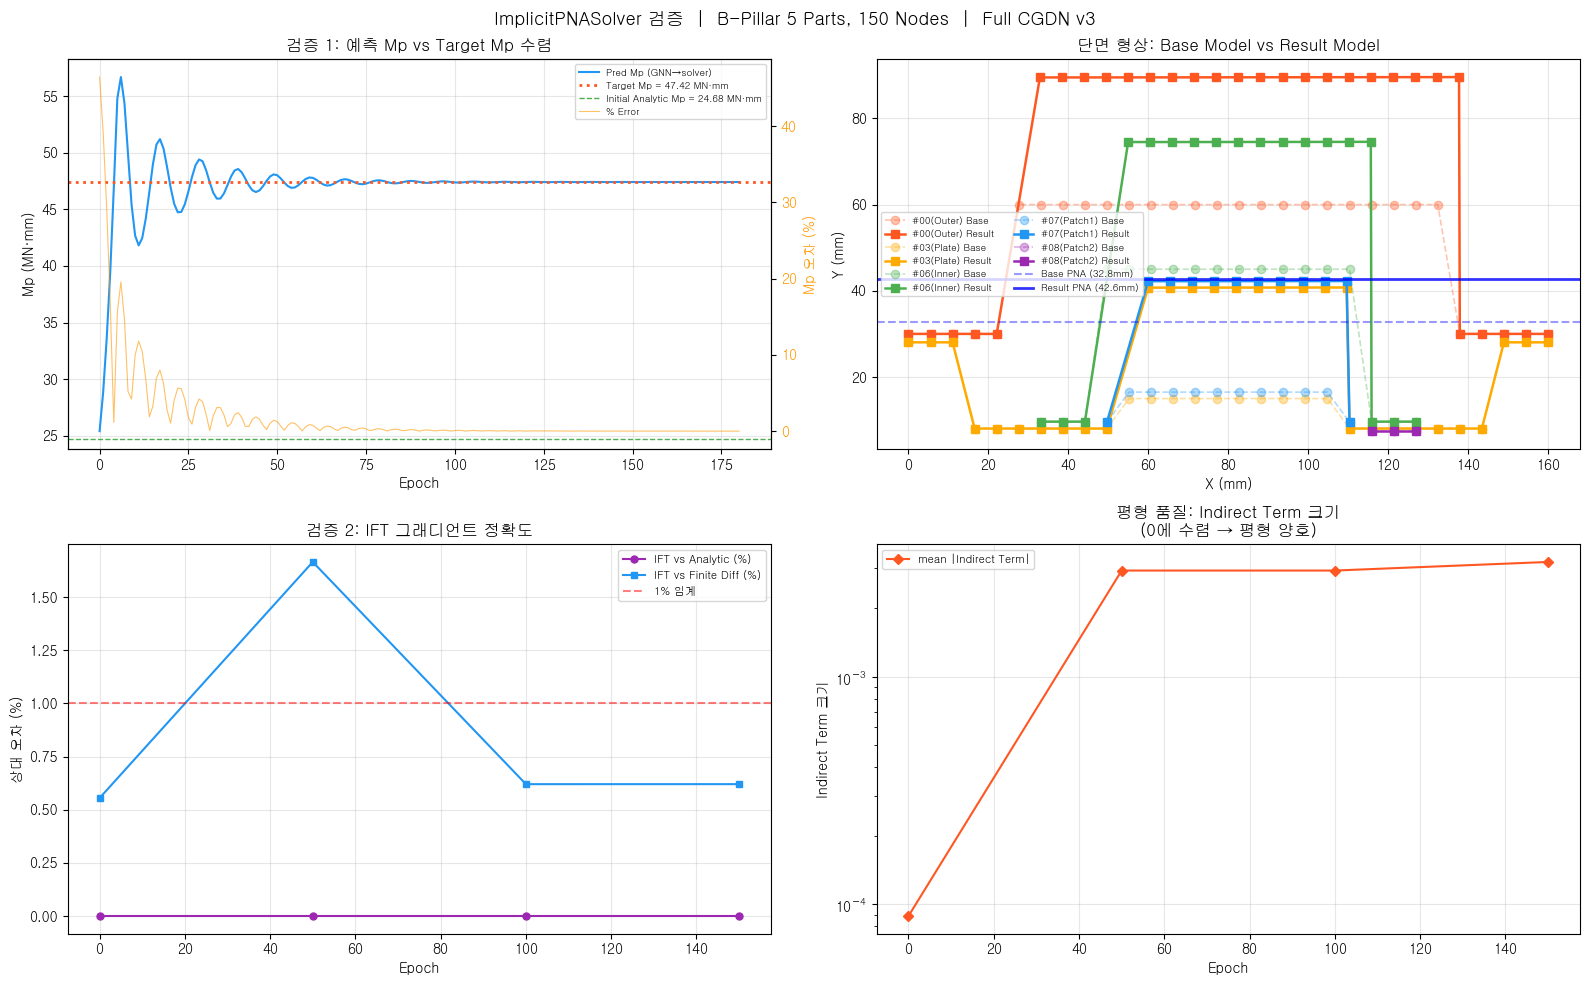


결과 저장: docs/validate_pna_result.png


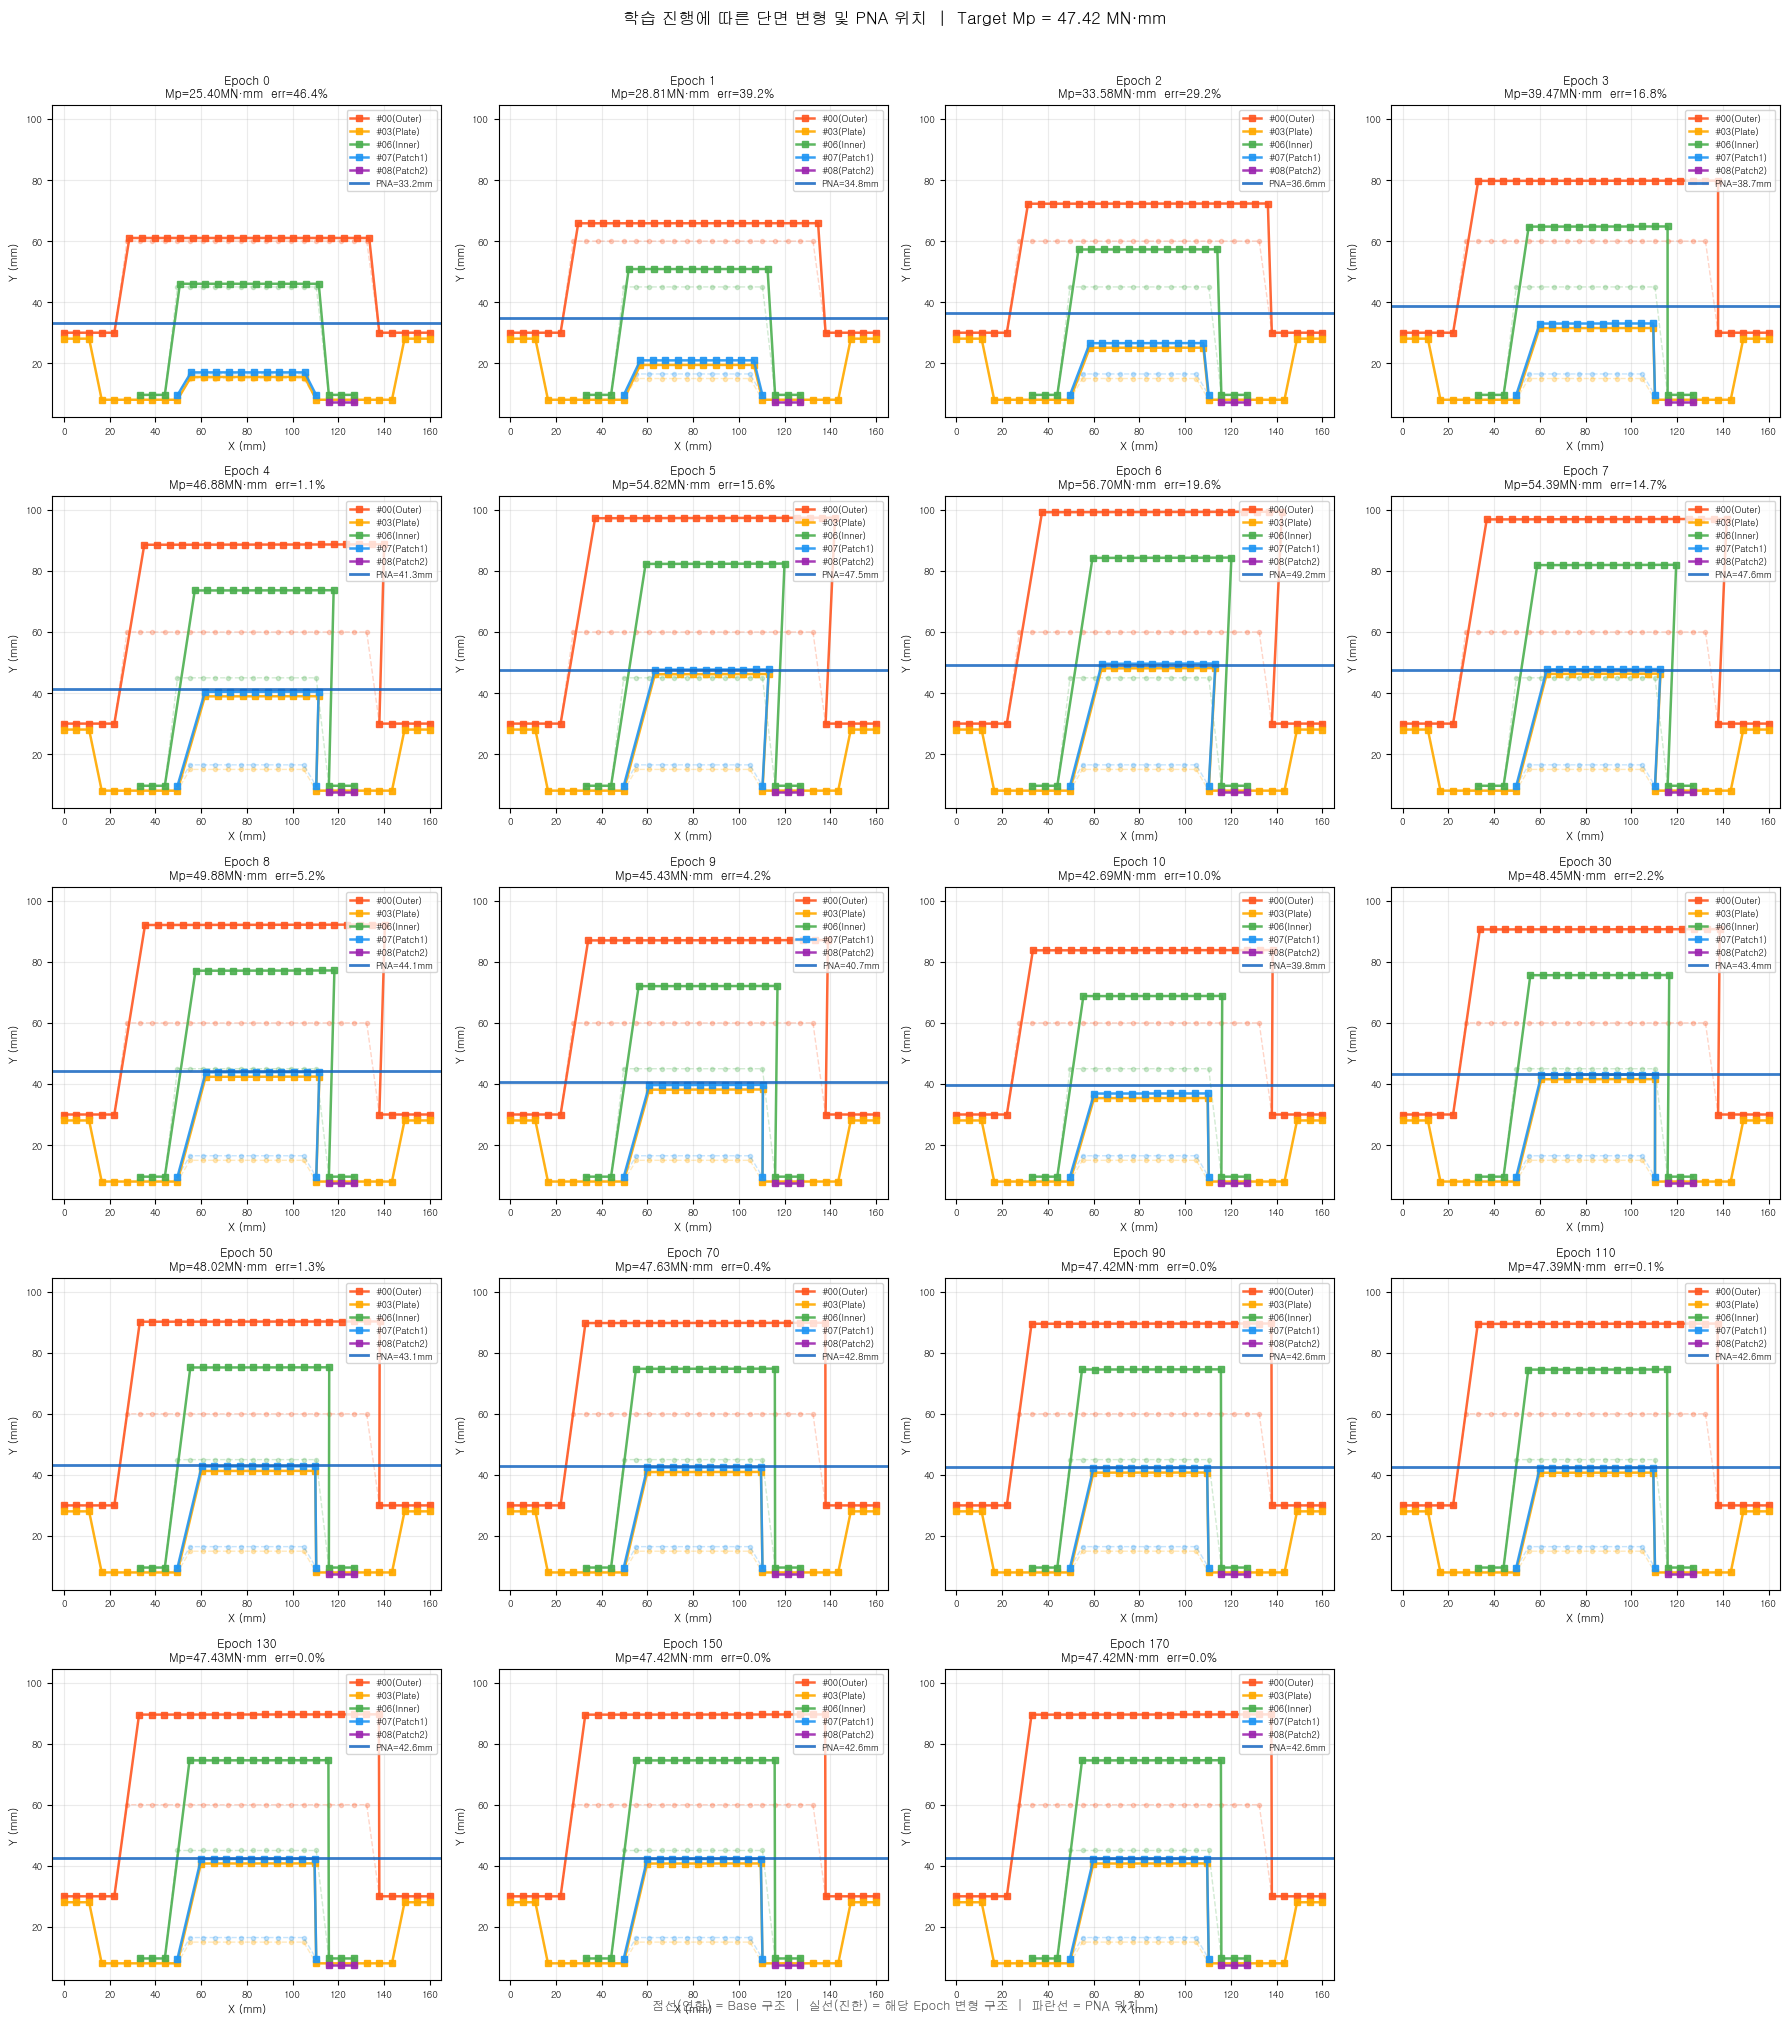


스냅샷 결과 저장: docs/validate_pna_epoch_snapshots.png

최종 결과 요약
  Initial Mp (analytic) :  24,678,652.00 N·mm
  Initial y_pna         :      32.813499 mm
  Final pred_mp         :     47,420,732 N·mm
  Target Mp             :     47,421,470 N·mm
  Final Error           :   0.00%
  Final grad_err (an)   :  0.000%
  Final grad_err (fd)   :  0.620%
  Final indirect_mag    : 3.1960e-03
  Snapshots saved       : 19 (epochs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 30, 50, 70, 90, 110, 130, 150, 170])
─────────────────────────────────────────────────────────────────
  단면 면적 (A = Σ L×t)
  Part            Initial (mm²)    Final (mm²)   Delta (mm²)
  ────────────── ────────────── ────────────── ─────────────
  #00(Outer)             482.93         618.76       +135.82
  #03(Plate)             315.48         394.27        +78.79
  #06(Inner)             246.90         341.49        +94.58
  #07(Patch1)             94.36         163.30        +68.94
  #08(Patch2)             17.66          17.66         +0

In [9]:
# ══════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    print("ImplicitPNASolver 알고리즘 정확도 검증")
    print("구조: B-Pillar 5 parts (#00/#03/#06/#07/#08), 150 nodes (파트당 30)")
    print("모델: CGDN v3 (hidden=128, layers=4, heads=4) — 전체 코드 그대로")

    data, node_registry = build_bpillar_section()
    print(f"\n데이터: nodes={data.x.shape} | edges={data.edge_index.shape}")

    # ── Section 2-A: Forward 검증 ──
    mp_solver, mp_analytic, y_pna_init = validate_forward(data)

    # ── Section 2-B: Backward 검증 ──
    validate_backward(data, n_check=8, eps=1e-2)

    # ── Section 2-C: Training + Epoch별 Mp 정확도 ──
    TARGET_MP = 47_421_470  # N·mm (B-Pillar 5-part HSS, PDF 기준 ~3.3E7 N·mm)
    history, base_coords, result_coords = run_training(
        data,
        target_mp_val=TARGET_MP,
        max_epochs=181,
        lr=1e-3,
        grad_check_interval=50,
        snapshot_interval=10,   # v3: 10 epoch마다 스냅샷
    )

    t_full = data.x[:, 6:7].cpu()
    fy_full = data.x[:, 7:8].cpu()
    result_coords_cpu = result_coords.cpu()

    y_pna_final = compute_y_pna_ref(result_coords_cpu, t_full, fy_full, data.edge_index.cpu())
    part_labels = data.x[:, 4].cpu().numpy()

    # ── 면적 계산 (Initial / Final) ──
    part_ids_t = data.x[:, 4].cpu().long()
    edge_index_cpu = data.edge_index.cpu()
    init_area_total, init_area_part = compute_section_area(
        base_coords.cpu(), t_full, edge_index_cpu, part_ids_t)
    final_area_total, final_area_part = compute_section_area(
        result_coords_cpu, t_full, edge_index_cpu, part_ids_t)

    # ── Section 3-A: 기존 4-Panel 시각화 ──
    visualize_results(history, base_coords.cpu(), result_coords_cpu, TARGET_MP,
                        fwd_mp_analytic=mp_analytic,
                        y_pna_init=y_pna_init,
                        y_pna_final=y_pna_final.item(),
                        part_labels=part_labels)

    # ── Section 3-B: v3 신규 — Epoch별 단면 변형 스냅샷 시각화 ──
    visualize_epoch_snapshots(history['snapshots'], base_coords.cpu(), TARGET_MP, part_labels=part_labels)

    # ── 최종 요약 ──
    final_pred = history['pred_mp'][-1]
    final_err  = abs(final_pred - TARGET_MP) / TARGET_MP * 100
    part_name_map = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)',
                     3: '#07(Patch1)', 4: '#08(Patch2)'}
    print(f"\n{'=' * 65}")
    print(f"최종 결과 요약")
    print(f"  Initial Mp (analytic) : {mp_analytic:>14,.2f} N·mm")
    print(f"  Initial y_pna         : {y_pna_init:>14.6f} mm")
    print(f"  Final pred_mp         : {final_pred:>14,.0f} N·mm")
    print(f"  Target Mp             : {TARGET_MP:>14,.0f} N·mm")
    print(f"  Final Error           : {final_err:>6.2f}%")
    if history['grad_epochs']:
        print(f"  Final grad_err (an)   : {history['grad_err_an'][-1]:>6.3f}%")
        print(f"  Final grad_err (fd)   : {history['grad_err_fd'][-1]:>6.3f}%")
        print(f"  Final indirect_mag    : {history['indirect_mag'][-1]:.4e}")
    print(f"  Snapshots saved       : {len(history['snapshots'])} (epochs: "
          f"{[s['epoch'] for s in history['snapshots']]})")
    print(f"{'─' * 65}")
    print(f"  단면 면적 (A = Σ L×t)")
    print(f"  {'Part':<14} {'Initial (mm²)':>14} {'Final (mm²)':>14} {'Delta (mm²)':>13}")
    print(f"  {'─'*14} {'─'*14} {'─'*14} {'─'*13}")
    all_pids = sorted(set(list(init_area_part.keys()) + list(final_area_part.keys())))
    for pid in all_pids:
        a_i = init_area_part.get(pid, 0.0)
        a_f = final_area_part.get(pid, 0.0)
        name = part_name_map.get(pid, f'Part{pid}')
        print(f"  {name:<14} {a_i:>14.2f} {a_f:>14.2f} {a_f - a_i:>+13.2f}")
    print(f"  {'─'*14} {'─'*14} {'─'*14} {'─'*13}")
    print(f"  {'Total':<14} {init_area_total:>14.2f} {final_area_total:>14.2f} "
          f"{final_area_total - init_area_total:>+13.2f}")
    print(f"{'=' * 65}")